## Config laden & Init

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import yaml

from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.metrics import r2_score, mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor
from pathlib import Path
from typing import Any


# Load Constants
NB_PATH = Path(globals()["__vsc_ipynb_file__"]).resolve()
ROOT = NB_PATH.parent.parent 
FIG_PATH = ROOT / "reports" / "figures"
CONFIG_PATH = ROOT / "configs" / "config.yaml"
with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

CSV_PATH = ROOT / config["data"]["csv_path"]

# Initialisierung
rs = config["modeling"]["random_state"]
np.random.seed(rs)
dpi = config["modeling"]["dpi"]
df = pd.read_csv(CSV_PATH, sep=config["data"]["sep"])
figsize = config["modeling"]["figsize"]
blue_color = config["modeling"]["blue_color"]
grey_color = config["modeling"]["grey_color"]
default_color = config["modeling"]["default_color"]
initial_train_size = config["modeling"]["train_size"]

# Init Plot
def save_plot(fig, title, save_path=FIG_PATH):
    filename = f"{title}.png"
    filepath = os.path.join(save_path, filename)
    fig.savefig(filepath, bbox_inches="tight", dpi=dpi)

def get_color_series(index, highlight_features, highlight_color=blue_color, default_color="lightgray"):
    return [highlight_color if feature in highlight_features else default_color for feature in index]

# CSV laden
df.columns = df.columns.str.strip()
df["KW"] = df.index
df["Datum"] = pd.to_datetime(config["data"]["start_date"]) + pd.to_timedelta(df["KW"] * 7, unit="D")
df["Monat_Jahr"] = df["Datum"].dt.to_period("M").dt.to_timestamp()

# Featureset
features = config["featuresset"]["features"]
target = config["featuresset"]["target"]

# Zielvariable
df[target] = df["Alle Abschlüsse"]

# Monatsaggregation
df_monthly = df.groupby(config["aggregation"]["groupby_col"]).agg(config["aggregation"]["agg_map"])

X = df_monthly[features].dropna()
y = df_monthly[target].loc[X.index]


## Baseline - Lineare Regression mit Expanding Window

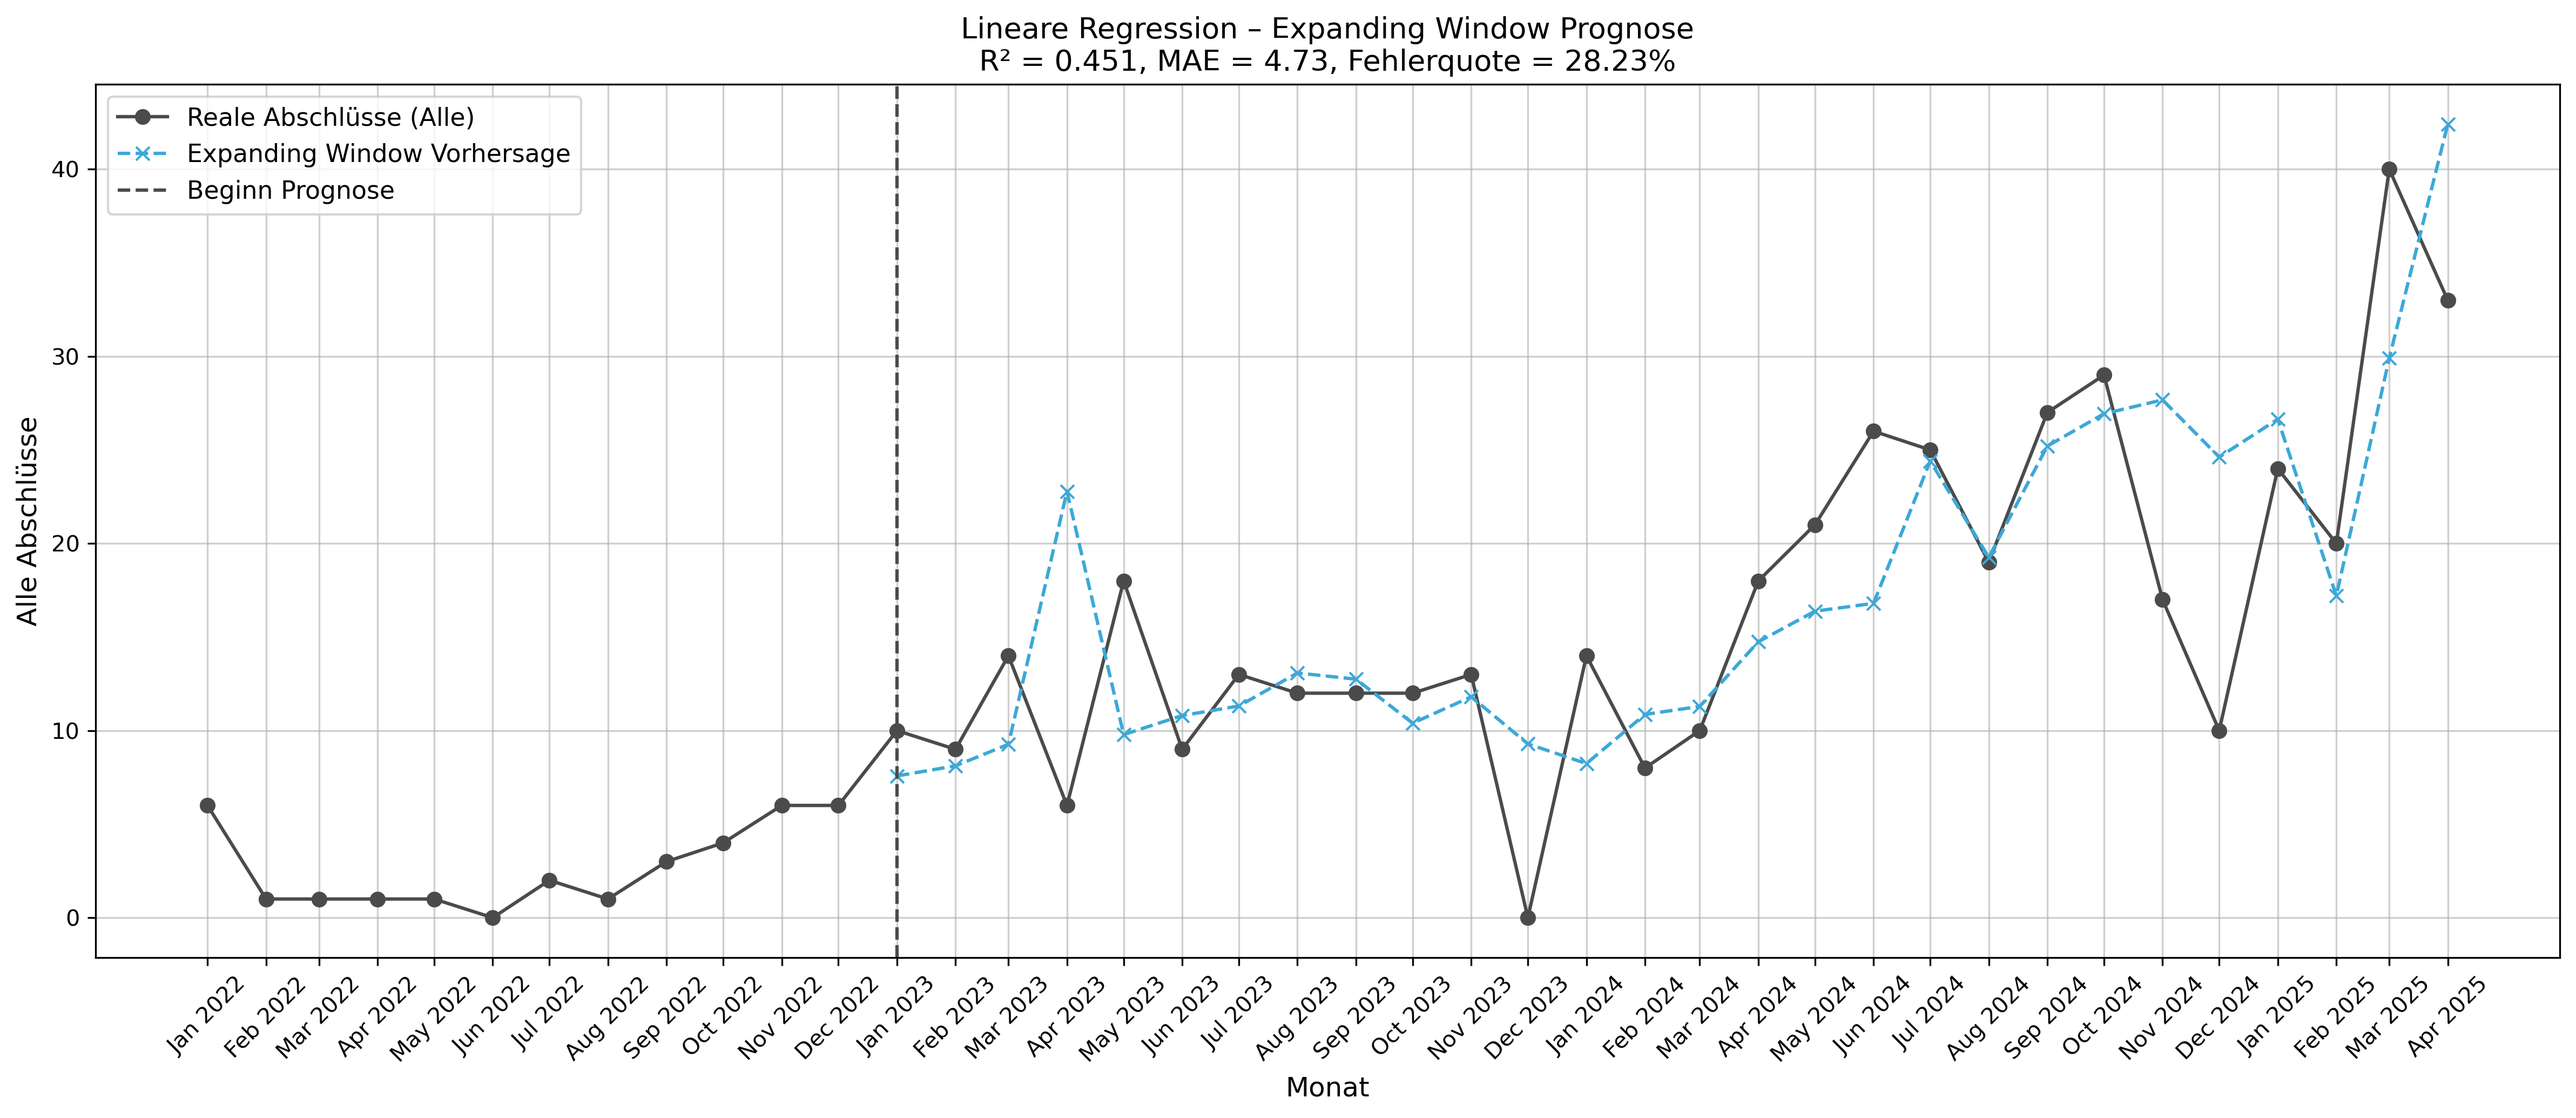

In [2]:
# Expanding Window Forecast
initial_train_size = initial_train_size
predictions = []
test_indices = []

for i in range(initial_train_size, len(X)):
    X_train = X.iloc[:i]
    y_train = y.iloc[:i]
    X_test = X.iloc[i:i+1]
    y_test = y.iloc[i:i+1]
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    predictions.extend(y_pred)
    test_indices.extend(y_test.index)

# Evaluation
y_test_full = y.loc[test_indices]
r2 = r2_score(y_test_full, predictions)
mae = mean_absolute_error(y_test_full, predictions)
fehlerquote = mae / np.mean(y_test_full) * 100

# Plot
title = "Lineare Regression – Expanding Window Prognose"
fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

ax.plot(y.index, y, label="Reale Abschlüsse (Alle)", marker='o', color=grey_color)
ax.plot(test_indices, predictions, label="Expanding Window Vorhersage", linestyle='--', marker='x', color=blue_color)
ax.axvline(x=y.index[initial_train_size], color=grey_color, linestyle="--", label="Beginn Prognose")

ax.set_title(f"{title}\nR² = {r2:.3f}, MAE = {mae:.2f}, Fehlerquote = {fehlerquote:.2f}%", fontsize=13)
ax.set_xlabel("Monat", fontsize=12)
ax.set_ylabel("Alle Abschlüsse", fontsize=12)
ax.set_xticks(y.index)
ax.set_xticklabels([d.strftime('%b %Y') for d in y.index], rotation=45, fontsize=10)
ax.legend(fontsize=11)
ax.grid(True, linestyle='-', alpha=0.6)

plt.tight_layout()
save_plot(fig, title)
plt.show()


## Baseline - SARIMAX mit Expanding Window

/opt/anaconda3/envs/ml-mac/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/ml-mac/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/ml-mac/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/ml-mac/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/ml-mac/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency in

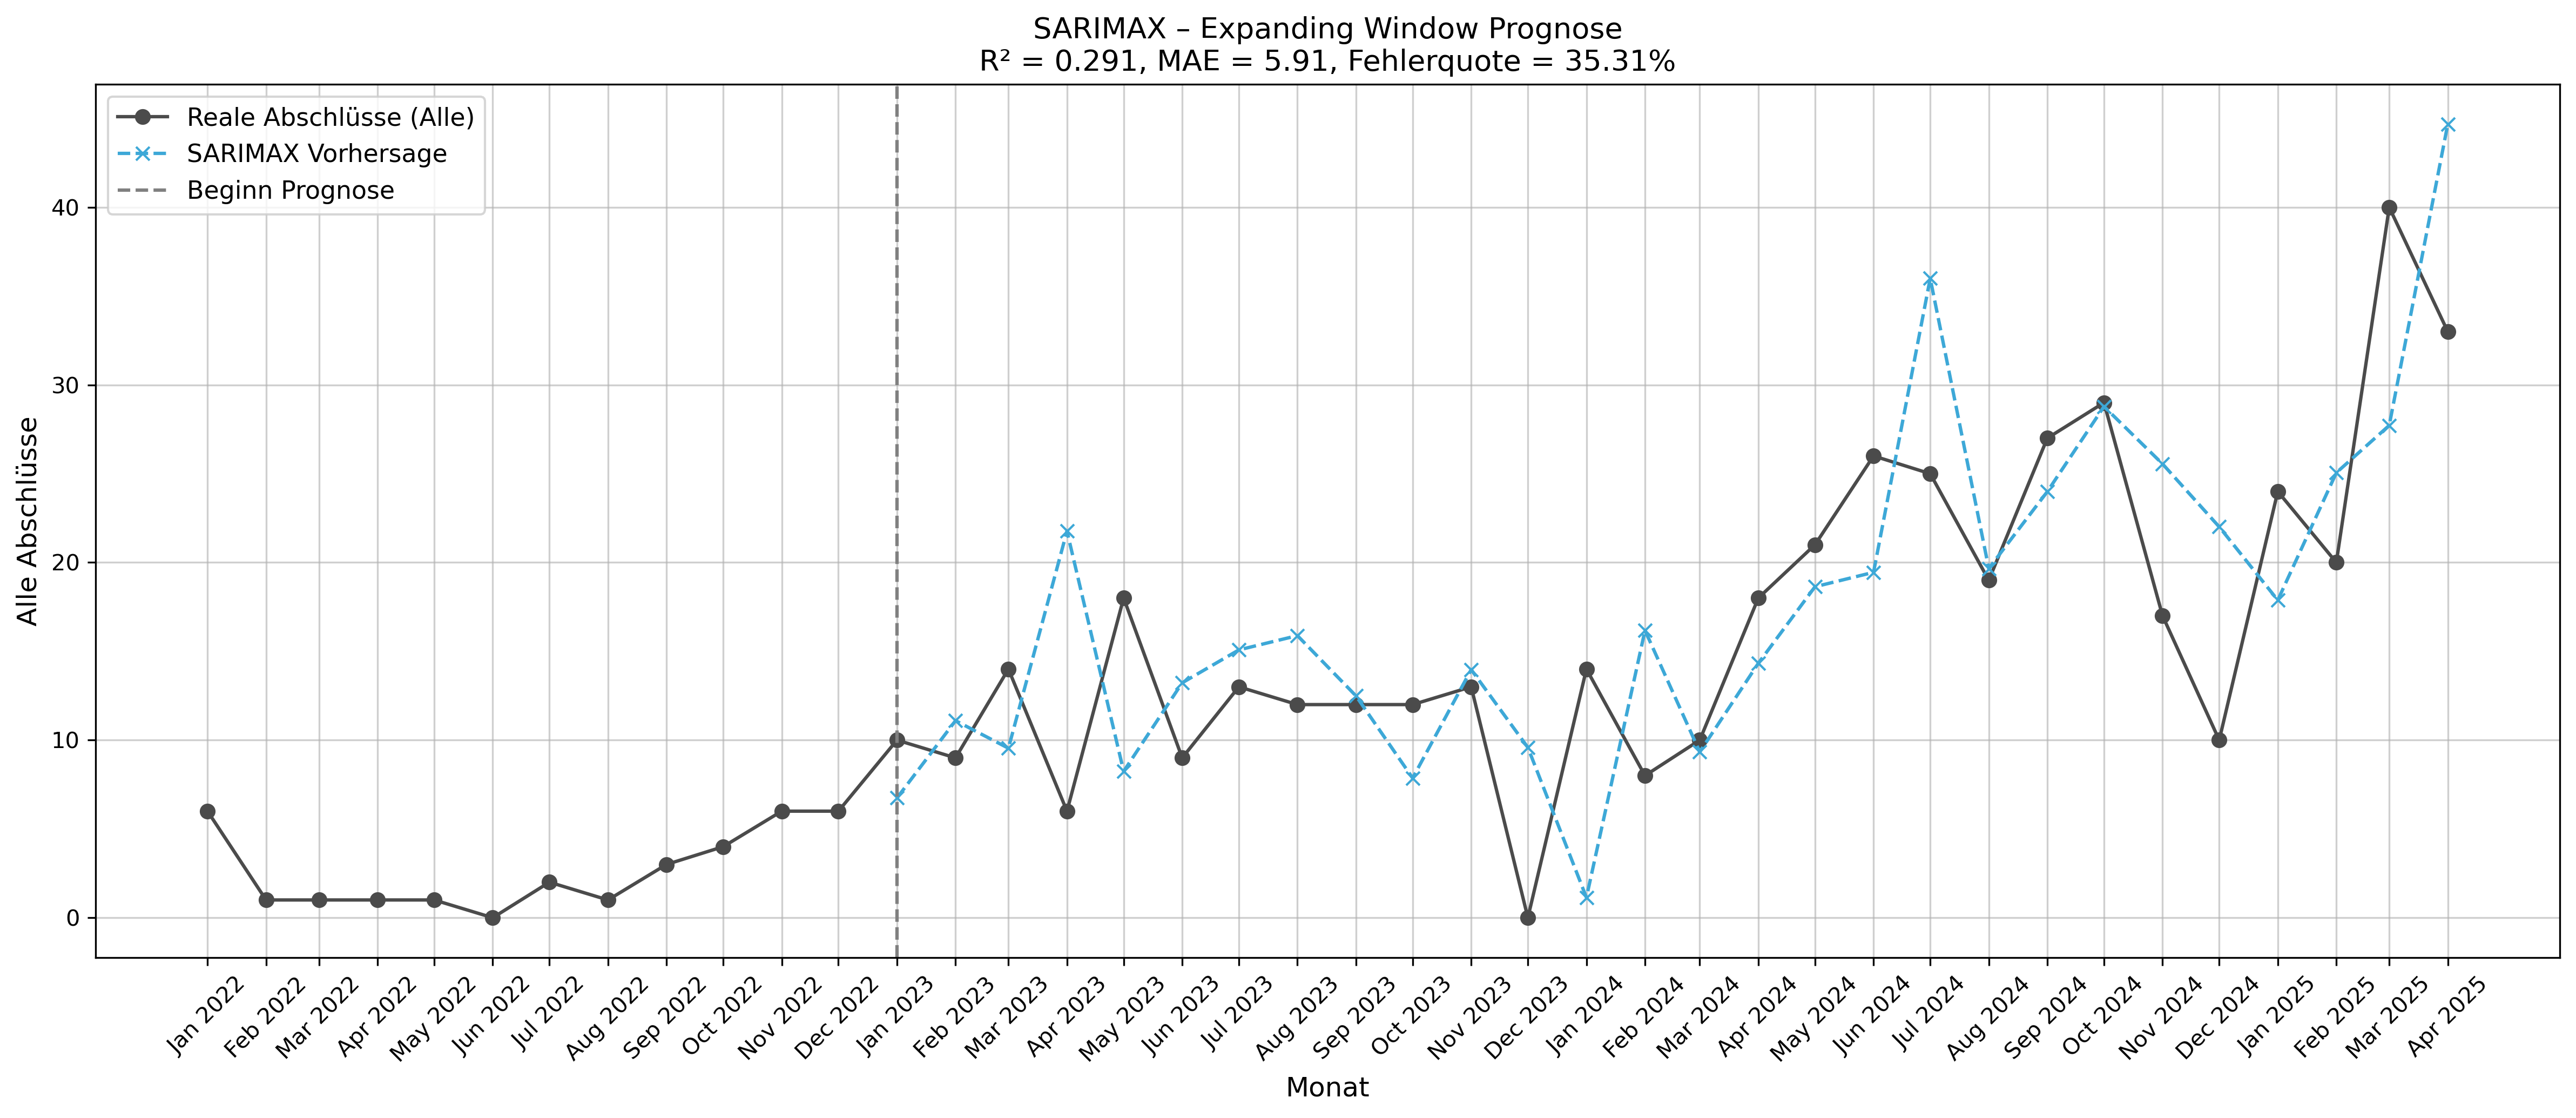

In [ ]:
# Expanding Window Setup
initial_train_size = initial_train_size
predictions = []
test_indices = []

# SARIMAX Parameter wie im 80/20 Split
order = (0, 1, 0)

for i in range(initial_train_size, len(X)):
    X_train = X.iloc[:i]
    y_train = y.iloc[:i]
    X_test = X.iloc[i:i+1]
    y_test = y.iloc[i:i+1]

    try:
        model = SARIMAX(endog=y_train, exog=X_train, order=order, enforce_stationarity=False, enforce_invertibility=False)
        results = model.fit(disp=False)
        forecast = results.forecast(steps=1, exog=X_test)
        predictions.extend(forecast)
        test_indices.extend(y_test.index)
    except Exception as e:
        print(f"Fehler bei Index {i}: {e}")

# Metriken
y_test_full = y.loc[test_indices]
r2 = r2_score(y_test_full, predictions)
mae = mean_absolute_error(y_test_full, predictions)
fehlerquote = mae / np.mean(y_test_full) * 100

# Plot
title = "SARIMAX – Expanding Window Prognose"
fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

ax.plot(y.index, y, label="Reale Abschlüsse (Alle)", marker='o', color=grey_color)
ax.plot(test_indices, predictions, label="SARIMAX Vorhersage", linestyle='--', marker='x', color=blue_color)
ax.axvline(x=y.index[initial_train_size], color=grey_color, linestyle="--", label="Beginn Prognose")

ax.set_title(f"{title}\nR² = {r2:.3f}, MAE = {mae:.2f}, Fehlerquote = {fehlerquote:.2f}%", fontsize=13)
ax.set_xlabel("Monat", fontsize=12)
ax.set_ylabel("Alle Abschlüsse", fontsize=12)
ax.set_xticks(y.index)
ax.set_xticklabels([d.strftime('%b %Y') for d in y.index], rotation=45, fontsize=10)
ax.legend(fontsize=11)
ax.grid(True, linestyle='-', alpha=0.6)

plt.tight_layout()
save_plot(fig, title)
plt.show()


## Baseline - XGBoost mit Expanding Window

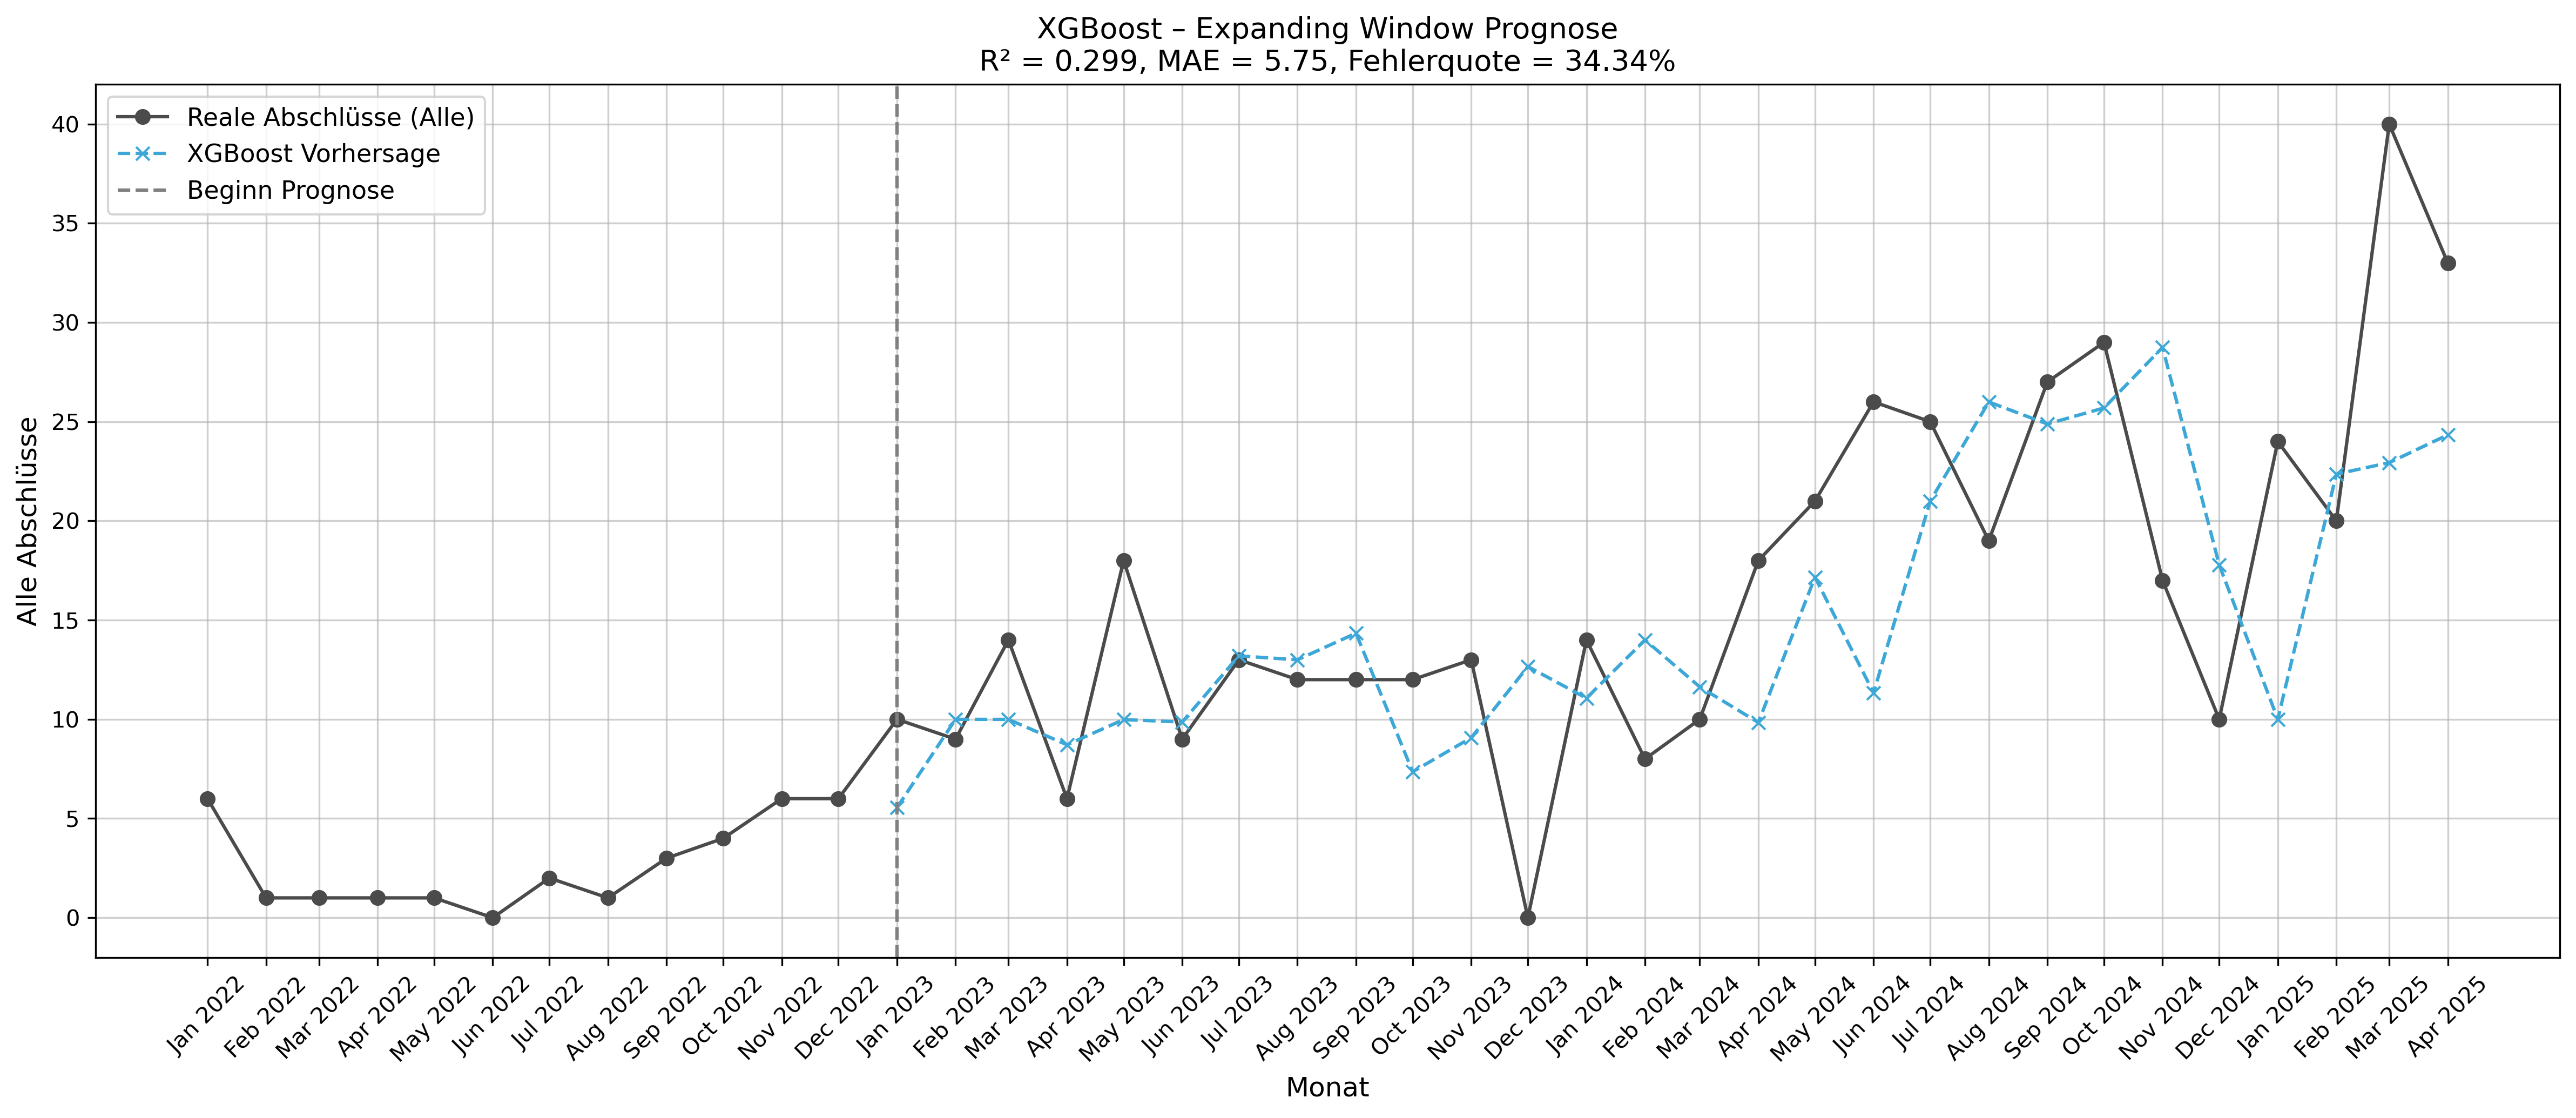

In [ ]:
# Expanding Window Forecast
initial_train_size = initial_train_size
predictions = []
test_indices = []

for i in range(initial_train_size, len(X)):
    X_train = X.iloc[:i]
    y_train = y.iloc[:i]
    X_test = X.iloc[i:i+1]
    y_test = y.iloc[i:i+1]

    model = XGBRegressor(random_state=rs, n_estimators=100)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    predictions.extend(y_pred)
    test_indices.extend(y_test.index)

# Metriken
y_test_full = y.loc[test_indices]
r2 = r2_score(y_test_full, predictions)
mae = mean_absolute_error(y_test_full, predictions)
fehlerquote = mae / np.mean(y_test_full) * 100

# Plot
title = "XGBoost – Expanding Window Prognose"
fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

ax.plot(y.index, y, label="Reale Abschlüsse (Alle)", marker='o', color=grey_color)
ax.plot(test_indices, predictions, label="XGBoost Vorhersage", linestyle='--', marker='x', color=blue_color)
ax.axvline(x=y.index[initial_train_size], color=grey_color, linestyle="--", label="Beginn Prognose")

ax.set_title(f"{title}\nR² = {r2:.3f}, MAE = {mae:.2f}, Fehlerquote = {fehlerquote:.2f}%", fontsize=13)
ax.set_xlabel("Monat", fontsize=12)
ax.set_ylabel("Alle Abschlüsse", fontsize=12)
ax.set_xticks(y.index)
ax.set_xticklabels([d.strftime('%b %Y') for d in y.index], rotation=45, fontsize=10)
ax.legend(fontsize=11)
ax.grid(True, linestyle='-', alpha=0.6)

plt.tight_layout()
save_plot(fig, title)
plt.show()

## Baseline - Lasso Regression mit Expanding Window

/opt/anaconda3/envs/ml-mac/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.012e-01, tolerance: 1.627e-01
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/envs/ml-mac/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.631e-01, tolerance: 1.627e-01
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/envs/ml-mac/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing

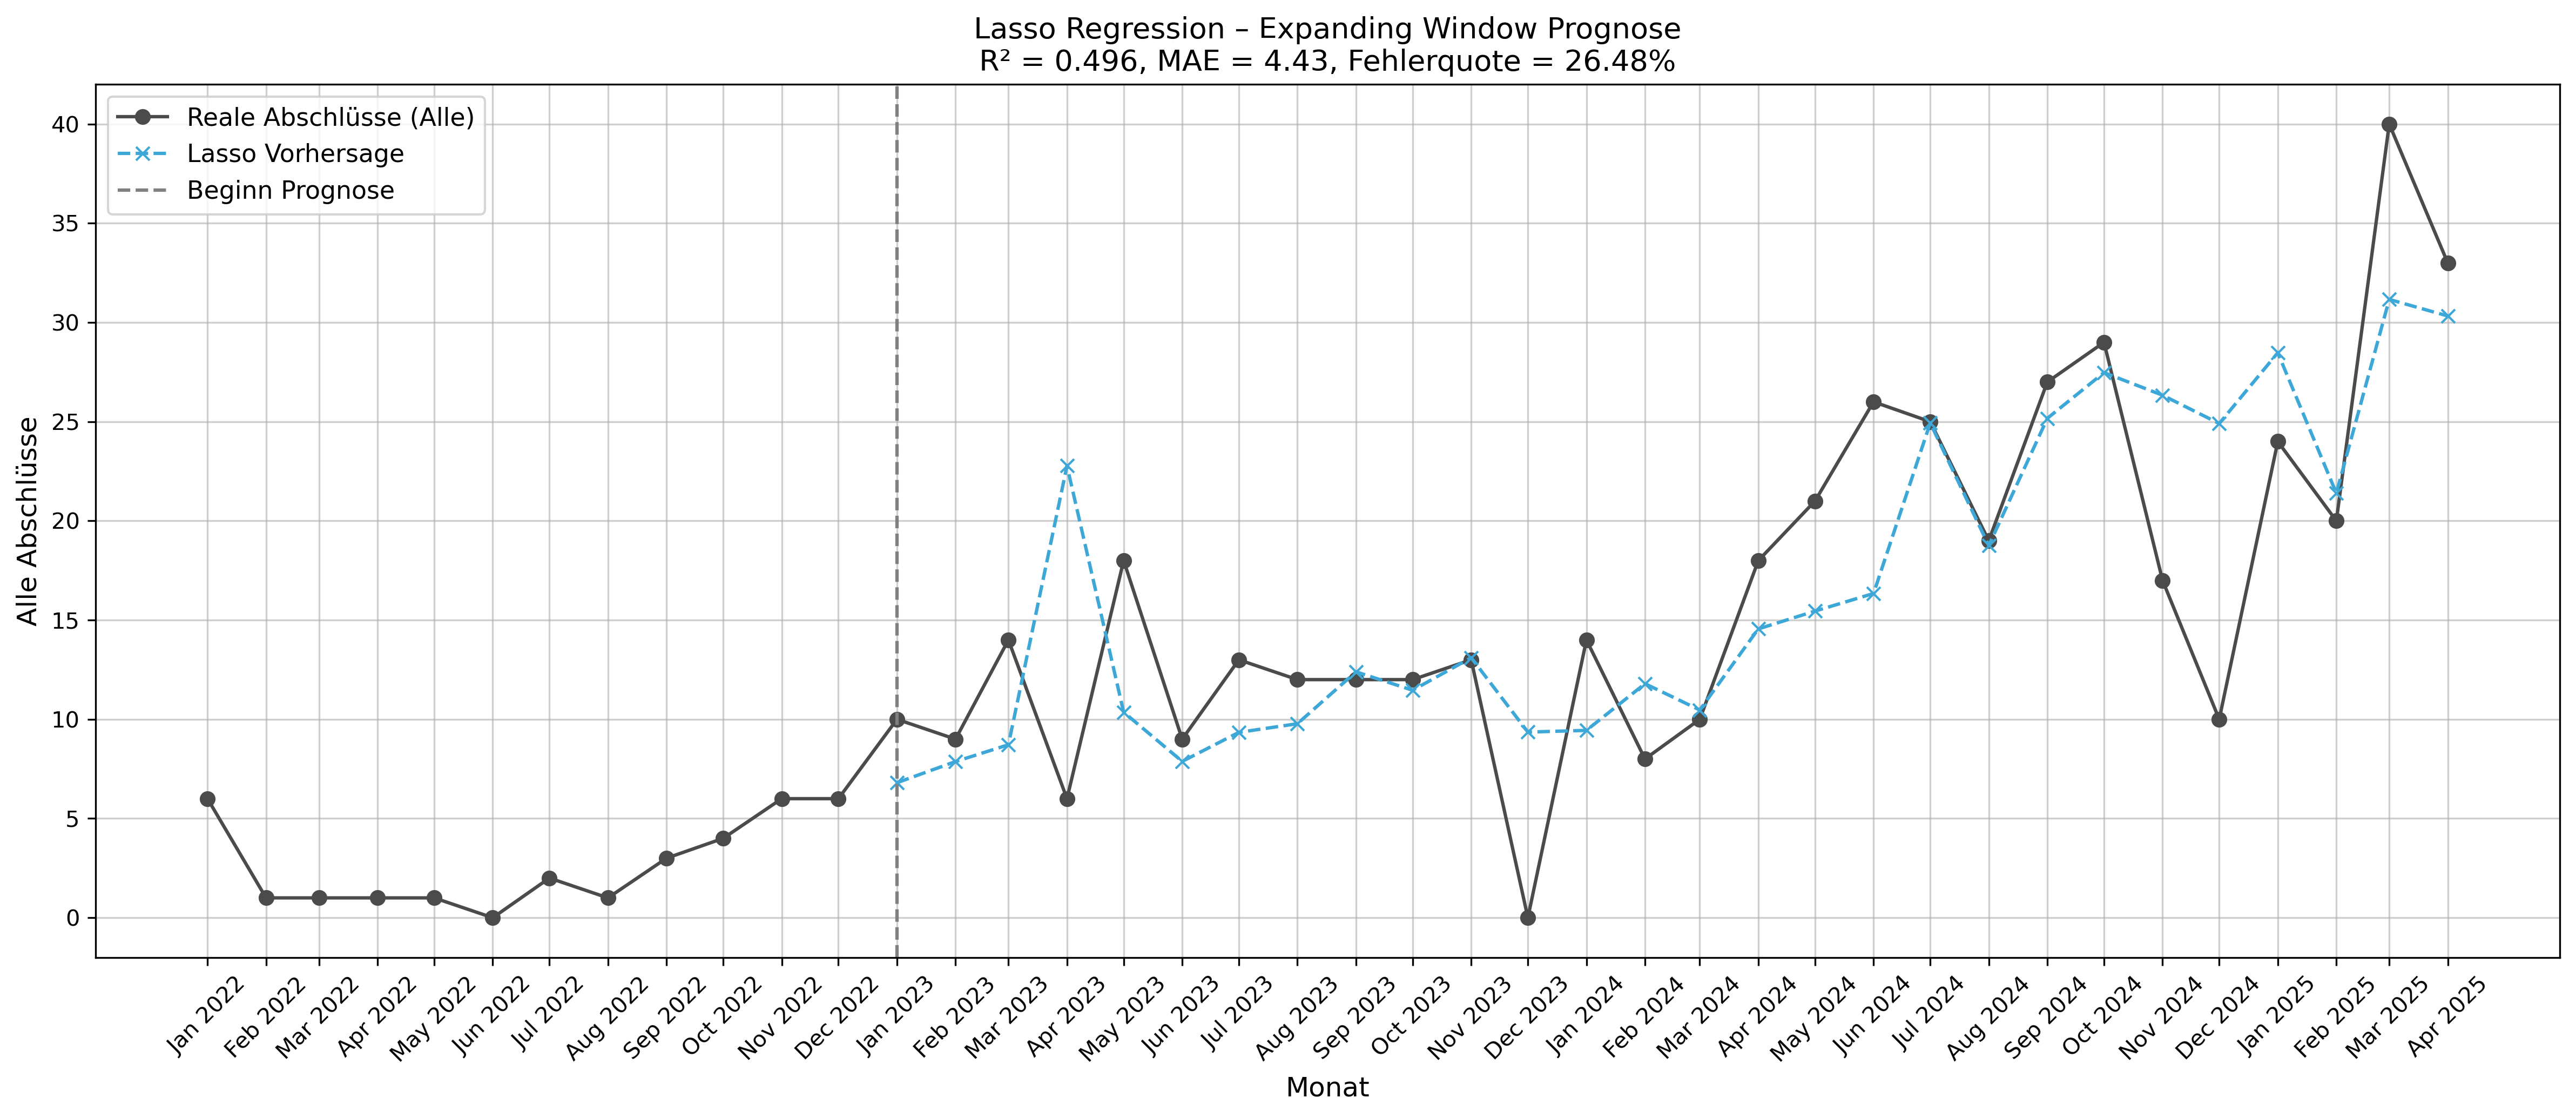

In [ ]:
# Expanding Window Forecast mit LassoCV
initial_train_size = initial_train_size
predictions = []
test_indices = []

for i in range(initial_train_size, len(X)):
    X_train = X.iloc[:i]
    y_train = y.iloc[:i]
    X_test = X.iloc[i:i+1]
    y_test = y.iloc[i:i+1]

    model = LassoCV(cv=5, random_state=rs)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    predictions.extend(y_pred)
    test_indices.extend(y_test.index)

# Metriken
y_test_full = y.loc[test_indices]
r2 = r2_score(y_test_full, predictions)
mae = mean_absolute_error(y_test_full, predictions)
fehlerquote = mae / np.mean(y_test_full) * 100

# Plot
title = "Lasso Regression – Expanding Window Prognose"
fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

ax.plot(y.index, y, label="Reale Abschlüsse (Alle)", marker='o', color=grey_color)
ax.plot(test_indices, predictions, label="Lasso Vorhersage", linestyle='--', marker='x', color=blue_color)
ax.axvline(x=y.index[initial_train_size], color=grey_color, linestyle="--", label="Beginn Prognose")

ax.set_title(f"{title}\nR² = {r2:.3f}, MAE = {mae:.2f}, Fehlerquote = {fehlerquote:.2f}%", fontsize=13)
ax.set_xlabel("Monat", fontsize=12)
ax.set_ylabel("Alle Abschlüsse", fontsize=12)
ax.set_xticks(y.index)
ax.set_xticklabels([d.strftime('%b %Y') for d in y.index], rotation=45, fontsize=10)
ax.legend(fontsize=11)
ax.grid(True, linestyle='-', alpha=0.6)

plt.tight_layout()
save_plot(fig, title)
plt.show()

## Baseline - Ridge Regression mit Expanding Window

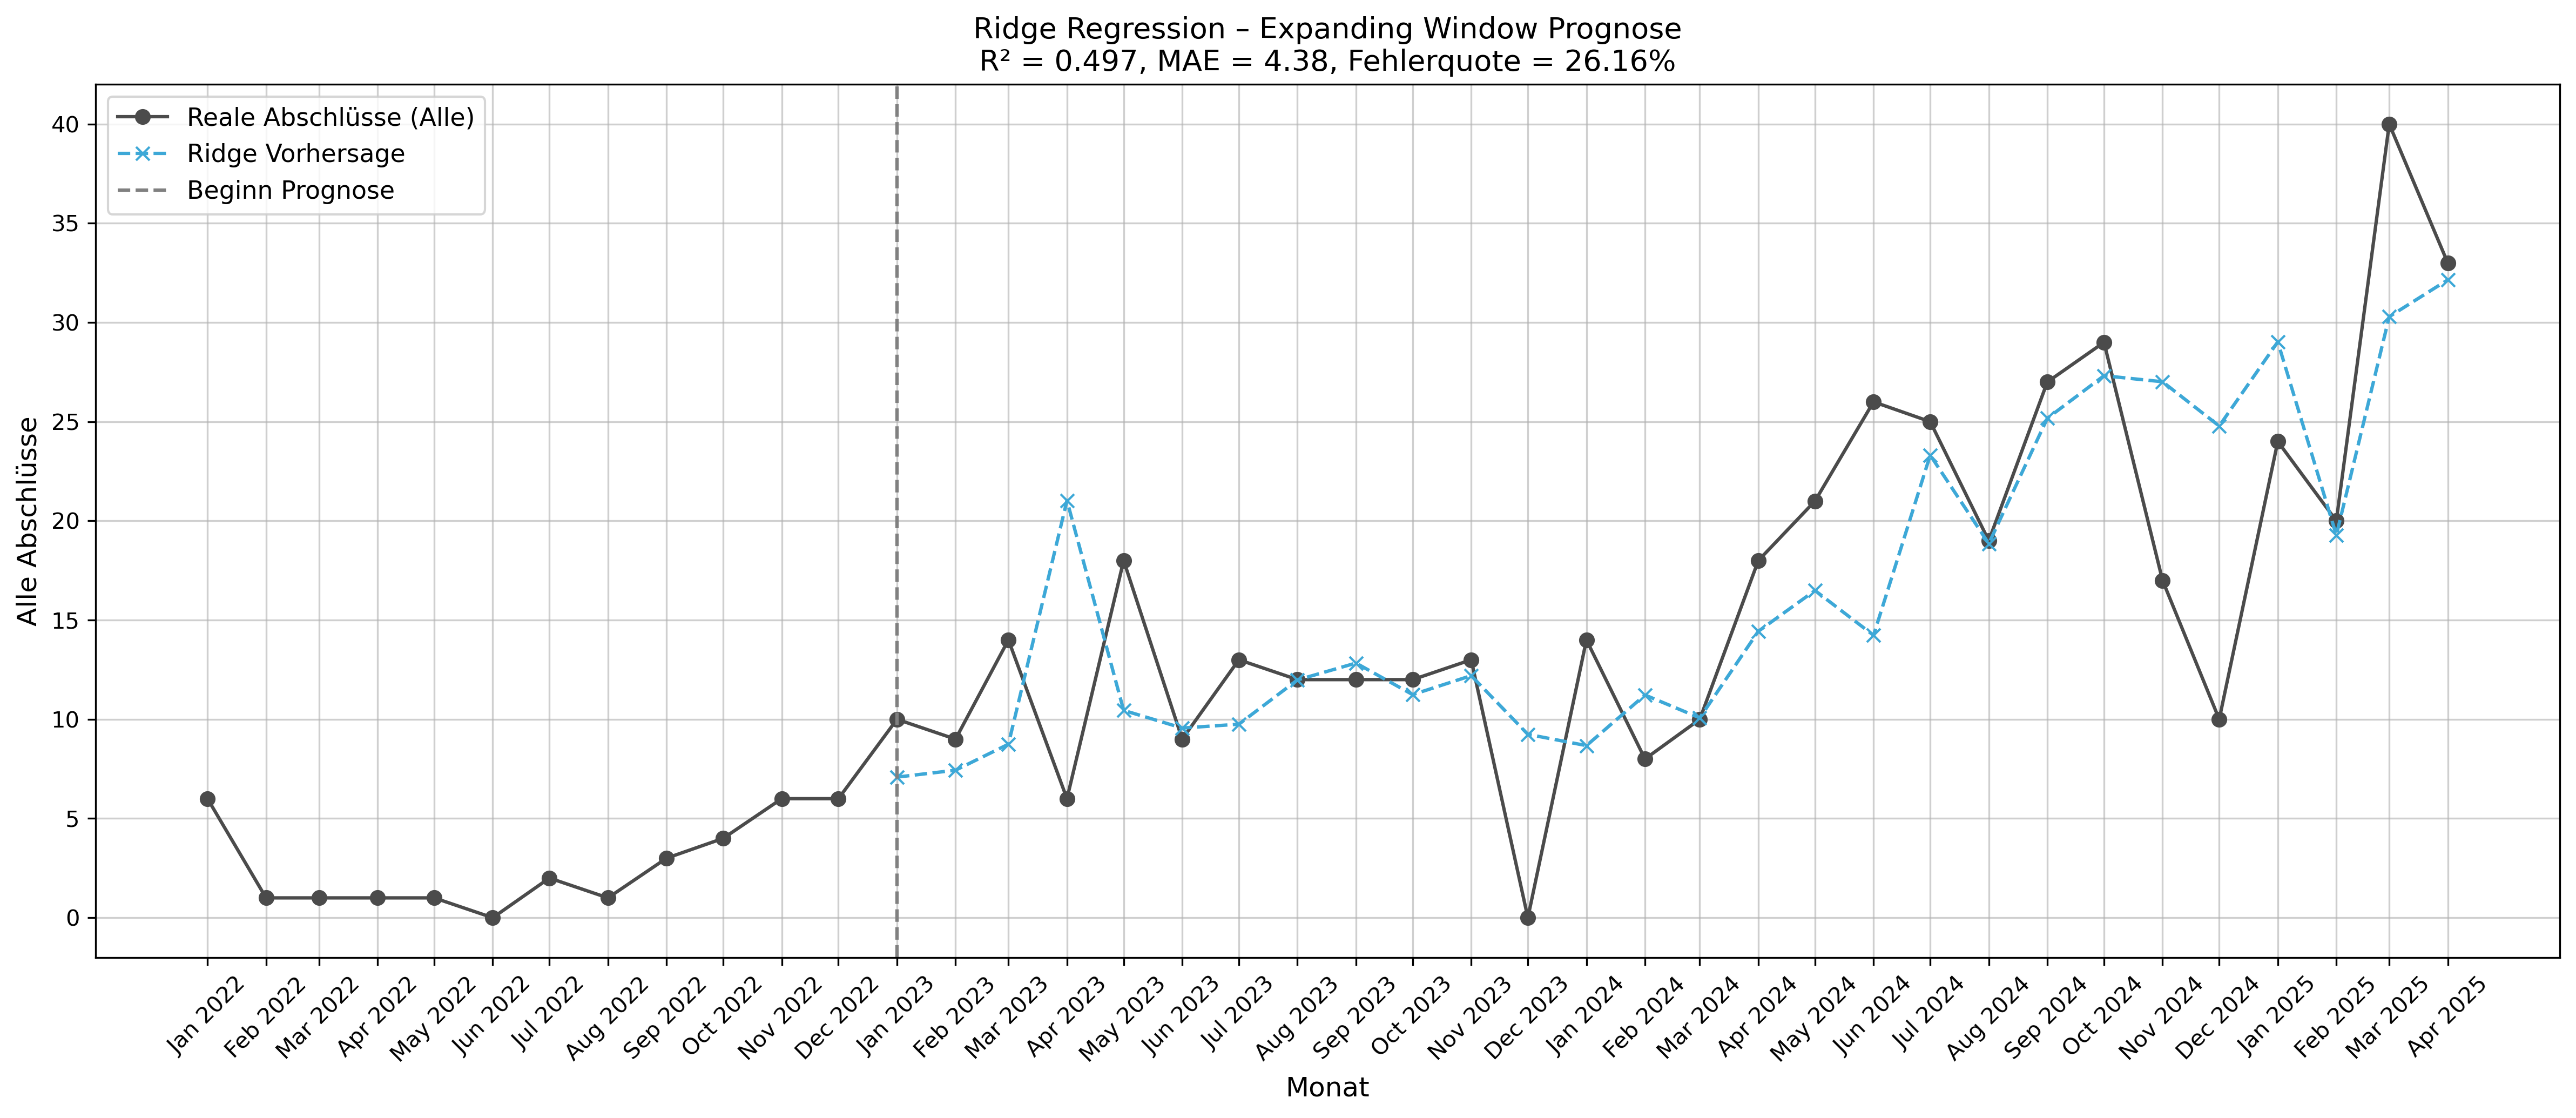

In [ ]:
# Expanding Window Forecast mit RidgeCV
initial_train_size = initial_train_size
predictions = []
test_indices = []

alphas = np.logspace(-3, 3, 100)

for i in range(initial_train_size, len(X)):
    X_train = X.iloc[:i]
    y_train = y.iloc[:i]
    X_test = X.iloc[i:i+1]
    y_test = y.iloc[i:i+1]

    model = RidgeCV(alphas=alphas, cv=5)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    predictions.extend(y_pred)
    test_indices.extend(y_test.index)

# Metriken
y_test_full = y.loc[test_indices]
r2 = r2_score(y_test_full, predictions)
mae = mean_absolute_error(y_test_full, predictions)
fehlerquote = mae / np.mean(y_test_full) * 100

# Plot
title = "Ridge Regression – Expanding Window Prognose"
fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

ax.plot(y.index, y, label="Reale Abschlüsse (Alle)", marker='o', color=grey_color)
ax.plot(test_indices, predictions, label="Ridge Vorhersage", linestyle='--', marker='x', color=blue_color)
ax.axvline(x=y.index[initial_train_size], color=grey_color, linestyle="--", label="Beginn Prognose")

ax.set_title(f"{title}\nR² = {r2:.3f}, MAE = {mae:.2f}, Fehlerquote = {fehlerquote:.2f}%", fontsize=13)
ax.set_xlabel("Monat", fontsize=12)
ax.set_ylabel("Alle Abschlüsse", fontsize=12)
ax.set_xticks(y.index)
ax.set_xticklabels([d.strftime('%b %Y') for d in y.index], rotation=45, fontsize=10)
ax.legend(fontsize=11)
ax.grid(True, linestyle='-', alpha=0.6)

plt.tight_layout()
save_plot(fig, title)
plt.show()
